# Pipeline de Regresión Logística para Predicción de Diabetes

**Dataset**: Diabetes Prediction Dataset (Kaggle)

**Objetivo**: Predecir si un paciente tiene diabetes (`diabetes = 1`) basado en 8 características demográficas y clínicas.

**Estrategia**:
1. Variables categóricas → Weight of Evidence (WOE) encoding
2. Variables numéricas → Optimal Binning con transformación WOE
3. Modelo → Regresión Logística con `class_weight='balanced'`
4. Selección de features → Backward Elimination evaluado con el pipeline completo
5. Interpretabilidad → Mappings WOE + train transformado

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (recall_score, 
                             roc_auc_score, 
                             average_precision_score,
                             fbeta_score,
                             confusion_matrix)

# Custom utils
import utils_pipeline_dhm as up
import utils as ut
import importlib
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


---
## 1. Carga y limpieza de datos

Filtramos:
- `bmi < 65`: outliers biomecánicamente inviables
- `gender != 'Other'`: categoría residual sin masa crítica para WOE

Normalizamos `smoking_history`: `'not current'` y `'ever'` se colapsan en `'former'` para reducir cardinalidad.

In [2]:
data = pd.read_csv('../data/diabetes_prediction_dataset.csv', sep=',')
print(f'Filas en bruto: {data.shape[0]}')

data = data[data['bmi'] < 65]
data = data[data['gender'] != 'Other']
print(f'Filas tras filtros: {data.shape[0]}')

smoking_mapping = {
    'No Info': 'No Info',
    'never': 'never',
    'former': 'former',
    'current': 'current',
    'not current': 'former',
    'ever': 'former'
}

X = data.drop(columns=['diabetes'])
y = data['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'\nDistribucion de target (train):\n{y_train.value_counts(normalize=True).to_string()}')

Filas en bruto: 100000
Filas tras filtros: 99935
Train: 79948  |  Test: 19987

Distribucion de target (train):
diabetes
0    0.915095
1    0.084905


---
## 2. Configuración del pipeline por columna

Usamos un `column_config` que especifica explícitamente qué transformación aplicar a cada columna:

| Columna | Transformación | Parámetros |
|--------|---------------|------------|
| `gender` | WOE | — |
| `smoking_history` | WOE | — |
| `hypertension` | WOE | — |
| `heart_disease` | WOE| — |
| `age` | Binning | 8 bins |
| `bmi` | Binning | 8 bins |
| `HbA1c_level` | Binning | 5 bins |
| `blood_glucose_level` | Binning | 4 bins |

`binary_cols` solo se usa para `TypeCaster` (convierte int → str antes de WOE).

In [3]:
binary_cols = ['hypertension', 'heart_disease']

column_config = {
    'gender':               {'transform': 'woe'},
    'smoking_history':      {'transform': 'woe'},
    'hypertension':         {'transform': 'woe'},
    'heart_disease':        {'transform': 'woe'},
    'age':                  {'transform': 'binning', 'max_bins': 8},
    'bmi':                  {'transform': 'binning', 'max_bins': 8},
    'HbA1c_level':         {'transform': 'binning', 'max_bins': 5},
    'blood_glucose_level':  {'transform': 'binning', 'max_bins': 4},
}
all_features = list(column_config.keys())
print(f'{len(all_features)} features configuradas: {all_features}')

8 features configuradas: ['gender', 'smoking_history', 'hypertension', 'heart_disease', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


---
## 3. Construcción del pipeline, para seleccion de variables.

**Estructura**:
1. `TypeCaster` — convierte `hypertension` y `heart_disease` de int (0/1) a string
2. `ColumnMapper` — normaliza `smoking_history` según el mapping definido
3. `ColumnConfigPreprocessor` — aplica WOE o binning según `column_config`

In [4]:
transformation_pipe = Pipeline([
    ('type_cast', up.TypeCaster(columns=binary_cols, dtype=str)),
    ('smoke_map', up.ColumnMapper(column='smoking_history', mapping=smoking_mapping)),
    ('preprocessor', up.ColumnConfigPreprocessor(column_config))
])

transformation_pipe.fit(X_train, y_train)
print('Pipeline de tranformación de variables listo!')

Pipeline de tranformación de variables listo!


---
## 4. Revision de correlaciones

Revisamos las correlaciones entre las variables transformadas utilizando woe.

Primeras filas de X_train transformado con WoE:


,gender,smoking_history,hypertension,heart_disease,age,bmi,HbA1c_level,blood_glucose_level
15163,-0.149763,-0.223560,0.225959,0.131395,0.353835,1.079046,1.809661,1.612593
41142,0.118977,0.774097,0.225959,0.131395,4.200568,2.398289,1.809661,1.612593
20453,0.118977,-0.118364,-1.438288,0.131395,-0.111718,0.295259,0.094640,0.199551
45884,-0.149763,-0.118364,0.225959,0.131395,2.168497,0.295259,0.094640,-1.809115
45480,0.118977,-0.118364,0.225959,0.131395,1.125706,0.295259,0.094640,-1.809115


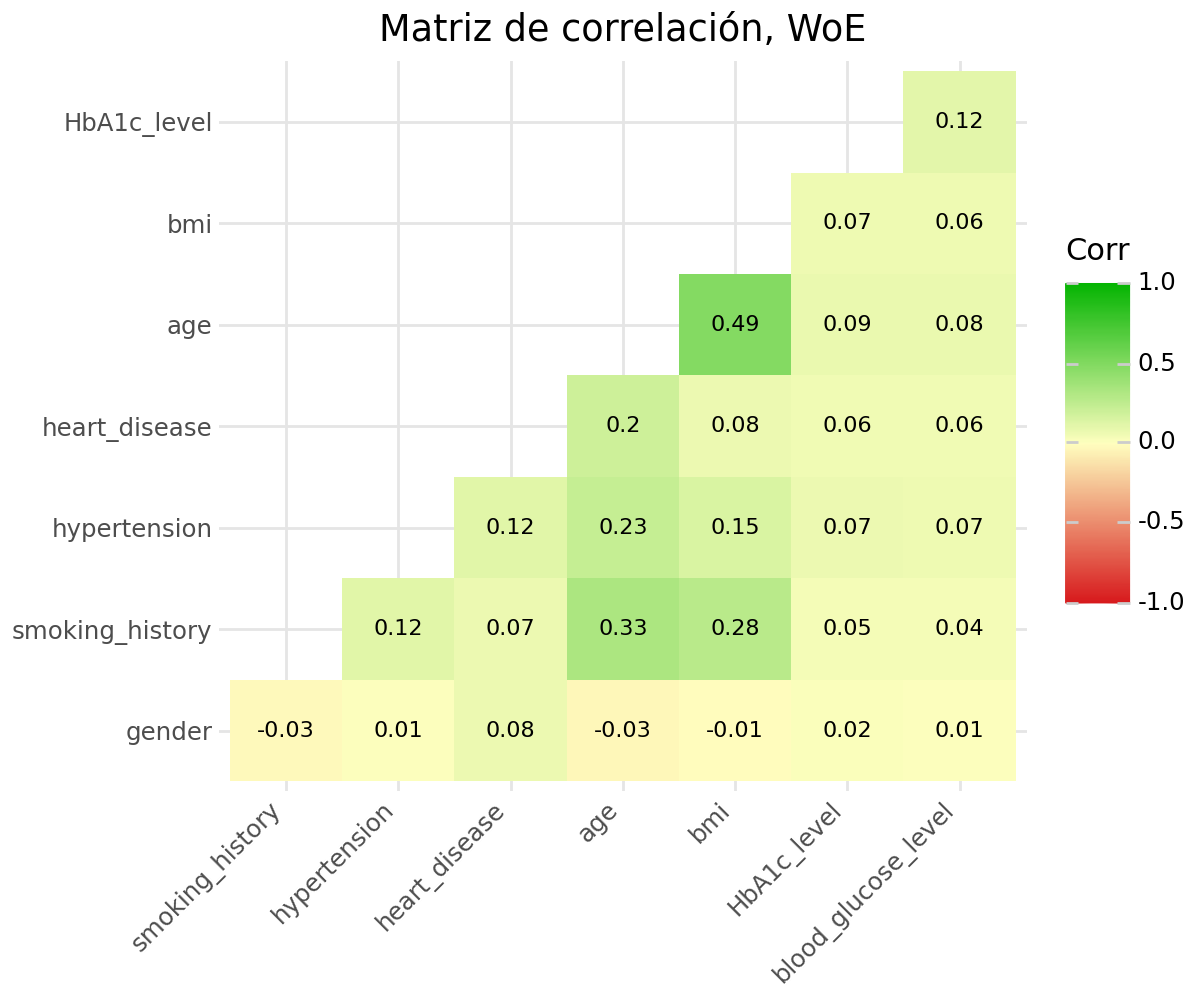

In [5]:
X_train_woe = transformation_pipe.transform(X_train)

print('Primeras filas de X_train transformado con WoE:')
display(X_train_woe.head())

ut.corr_plot(X_train_woe,
             X_train_woe.columns.tolist(),
             (6,5),
             title='Matriz de correlación, WoE'
            ).show()

No se observan, variables transformadas a WoE que tengan una correlación con valor absoluto mayor a 0.5, No se descartan variables.

---
# 5. Selección de variables

## 5.1 Revision de IV

In [6]:
summary_iv = []
for var in X_train_woe.columns:  # Excluimos la variable target
    summary_iv.append(up.iv_variable(X_train_woe.join(y_train),var,'diabetes'))

summary_iv = pd.DataFrame(summary_iv)
summary_iv = summary_iv.sort_values('IV total', ascending=False)
summary_iv = summary_iv.reset_index(drop = True)
summary_iv

,Variable,Count,Non_Event,Event,count_%,event_rate,IV total
0,HbA1c_level,79948,73160,6788,1.0,0.084905,1.594352
1,age,79948,73160,6788,1.0,0.084905,1.341296
2,blood_glucose_level,79948,73160,6788,1.0,0.084905,1.212423
3,bmi,79948,73160,6788,1.0,0.084905,0.651763
4,hypertension,79948,73160,6788,1.0,0.084905,0.316525
5,smoking_history,79948,73160,6788,1.0,0.084905,0.242994
6,heart_disease,79948,73160,6788,1.0,0.084905,0.211258
7,gender,79948,73160,6788,1.0,0.084905,0.017789


Dado el bajo IV de la variable `gender` (<0.02), la descartamos, actualizamos las columnas y el conjunto de transformaciones.

In [7]:
columns_to_drop = summary_iv[summary_iv['IV total'] < 0.02]['Variable'].tolist()
print(f'Variables a eliminar por bajo IV (<0.02): {columns_to_drop}')

# Actualizamos X_train, X_test, column_config,
# eliminando las columnas con bajo IV
X_train.drop(columns=columns_to_drop, inplace=True)
X_test.drop(columns=columns_to_drop, inplace=True)
column_config = {k: v for k, v in column_config.items()
                 if k in X_train.columns}

Variables a eliminar por bajo IV (<0.02): ['gender']


## 5.2 Regresion Lasso para seleccionar variables.

Con las 7 variables del paso anterior utilizaremos Lasso con validación cruzada.

In [8]:
# Pipeline de selección de variables con LASSO
selector_pipe = Pipeline([
    ('type_cast', up.TypeCaster(columns=binary_cols, dtype=str)),
    ('smoke_map', up.ColumnMapper(column='smoking_history', mapping=smoking_mapping)),
    ('preprocessor', up.ColumnConfigPreprocessor(column_config)),
    ('model', LogisticRegression(l1_ratio=1, # Only LASSO
                                 solver='saga',
                                 max_iter=1000,
                                 random_state=42,
                                 class_weight='balanced',
    ))
])

# StrifiedKFold para la validación cruzada en la selección de variables
selector_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parametros a evaluar en GridSearchCV para la regularización LASSO (C = 1 / lambda)
param_grid = {'model__C': np.logspace(-4, 4, 100)}

# GridSearchCV para encontrar el mejor valor de C (regularización) 
# en el modelo LASSO dentro del pipeline de selección de variables
selector_grid = GridSearchCV(selector_pipe,
                    param_grid,
                    cv=selector_cv,
                    scoring='average_precision',
                    refit='average_precision',
                    n_jobs=-1
                )

selector_grid.fit(X_train, y_train)
print('GridSearch de seleccion de variables con LASSO listo!')

GridSearch de seleccion de variables con LASSO listo!


In [9]:
# Best fitted model (already retrained on full data)
best_model = selector_grid.best_estimator_.named_steps['model']

# Coefficients
coefs = best_model.coef_

# Best C from GridSearch
best_C = best_model.C
#best_C = selector_grid.best_params_['model__C']

# Convert to lambda (alpha)
best_lambda = 1 / best_C

print(f"Mejor C: {best_C}")
print(f"Mejor lambda (alpha): {best_lambda}")

Mejor C: 0.012618568830660211
Mejor lambda (alpha): 79.24828983539169


Revisamos las variables seleccionadas.

In [10]:
# Estimaciones de los coeficientes del mejor modelo
coefficients = coefs.flatten()
coefs = pd.DataFrame({'coef': coefs[0], 'feature': X_train.columns})
coefs = coefs[coefs.coef != 0].reset_index(drop=True)
coefs.sort_values('coef', ascending=True)

,coef,feature
5,-0.990232,HbA1c_level
6,-0.968267,blood_glucose_level
3,-0.791489,smoking_history
4,-0.707363,bmi
1,-0.496269,hypertension
2,-0.461950,heart_disease
0,-0.360308,age


Luego de hacer la selección de variables utilizando Lasso, revisamos los coeficientes y ninguna de las variables tiene coeficiente en 0 o cercano a 0, por lo cual no se descarta ninguna y el modelo final se construye con las 7 variables.

---
# 6. Modelos

## 6.1 Optimización de parametros con Cross Validation

- **Parámetro**: `model__C` (inverso de regularización L2)
- **Grid**: logspace(-4, 4, 100)
- **CV**: 5-fold estratificado
- **Refit**: PR-AUC (métrica relevante para clases desbalanceadas)

In [11]:
# Pipeline para optimizar C
model_pipe = Pipeline([
    ('type_cast', up.TypeCaster(columns=binary_cols, dtype=str)),
    ('smoke_map', up.ColumnMapper(column='smoking_history', mapping=smoking_mapping)),
    ('preprocessor', up.ColumnConfigPreprocessor(column_config)),
    ('model', LogisticRegression(solver='saga',
                                 max_iter=1000,
                                 random_state=42,
                                 class_weight='balanced'
    ))
])

# StrifiedKFold para la validación cruzada en la selección de variables
model_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parametros a evaluar en GridSearchCV para la regularización LASSO (C = 1 / lambda)
param_grid = {'model__C': np.logspace(-4, 4, 100)}

# GridSearchCV para encontrar el mejor valor de C (regularización) 
# en el modelo LASSO dentro del pipeline de selección de variables
model_grid = GridSearchCV(model_pipe,
                    param_grid,
                    cv=model_cv,
                    scoring='average_precision',
                    refit='average_precision',
                    n_jobs=-1
                )

model_grid.fit(X_train, y_train)
print('GridSearch de modelo final listo!')

GridSearch de modelo final listo!


Revisamos el top 5 de mejores C

In [12]:
cv_results = pd.DataFrame(model_grid.cv_results_)
cv_results = (cv_results[['param_model__C', 'mean_test_score', 'std_test_score','rank_test_score']]
              .sort_values('mean_test_score', ascending=False)
              .head(5)
)

cv_results.columns = ['C','PR-AUC (media)','PR-AUC (std)','Rank']

display(cv_results.style.format({
    'ROC-AUC (media)': '{:.6f}', 
    'PR-AUC (media)': '{:.6f}',
    'ROC-AUC (std)': '{:.6f}', 
    'PR-AUC (std)': '{:.6f}'
}))

best_params = model_grid.best_params_
best_score = model_grid.best_score_
print(f'\nMejor C = {best_params["model__C"]}')
print(f'PR-AUC media en CV = {best_score:.6f}')

,C,PR-AUC (media),PR-AUC (std),Rank
21,0.004977,0.678001,0.004586,1
20,0.004132,0.678000,0.004580,2
22,0.005995,0.677985,0.004545,3
19,0.003430,0.677961,0.004584,4
23,0.007221,0.677953,0.004536,5



Mejor C = 0.004977023564332114
PR-AUC media en CV = 0.678001


## 6.2 Modelo Final

In [13]:
final_model_pipe = Pipeline([
    ('type_cast', up.TypeCaster(columns=binary_cols, dtype=str)),
    ('smoke_map', up.ColumnMapper(column='smoking_history', mapping=smoking_mapping)),
    ('preprocessor', up.ColumnConfigPreprocessor(column_config)),
    ('model', LogisticRegression(C=best_params['model__C'],
                                 solver='saga',
                                 max_iter=1000,
                                 random_state=42,
                                 class_weight='balanced'
    ))
])

final_model_pipe.fit(X_train, y_train)
print('Modelo final entrenado con mejor C encontrado en GridSearchCV!')

Modelo final entrenado con mejor C encontrado en GridSearchCV!


### Coeficientes del modelo

In [14]:
final_coefs = final_model_pipe.named_steps['model'].coef_[0]
fnames = final_model_pipe.named_steps['preprocessor'].get_feature_names_out()
coef_df = pd.DataFrame({
    'feature': fnames,
    'coef': final_coefs,
    'odds_ratio': np.exp(final_coefs)
}).sort_values('coef', ascending=True)

display(coef_df.style.format({'coef': '{:.4f}', 'odds_ratio': '{:.4f}'}))

,feature,coef,odds_ratio
5,HbA1c_level,-0.9758,0.3769
6,blood_glucose_level,-0.9512,0.3863
3,age,-0.7788,0.4589
4,bmi,-0.6901,0.5015
1,hypertension,-0.4899,0.6127
2,heart_disease,-0.4558,0.6340
0,smoking_history,-0.3664,0.6932


---
# 7. Evaluación del modelo final

## 7.1 Metricas
- PR-AUC
- ROC-AUC
- Recall

Calculamos el threshold óptimo sobre **train** maximizando F2-score, para luego evaluar recall en train y test.

In [21]:
train_preds = final_model_pipe.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
opt_t = thresholds[np.argmax([fbeta_score(y_train, (train_preds >= t).astype(int), beta=2) for t in thresholds])]
print(f'Threshold optimo (max F2 en train): {opt_t:.3f}\n')

Threshold optimo (max F2 en train): 0.650



In [16]:
metrics = []
for name, X, y in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    preds = final_model_pipe.predict_proba(X)[:, 1]
    metrics.append({
        'Set': name,
        'PR-AUC': average_precision_score(y, preds),
        'ROC-AUC': roc_auc_score(y, preds),
        'Recall': recall_score(y, (preds >= opt_t).astype(int))
    })

display(pd.DataFrame(metrics).style.format({
    'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Recall': '{:.4f}'
}))

,Set,PR-AUC,ROC-AUC,Recall
0,Train,0.6809,0.9373,0.7867
1,Test,0.6801,0.9402,0.7820


## 7.2 Curvas PR-AUC

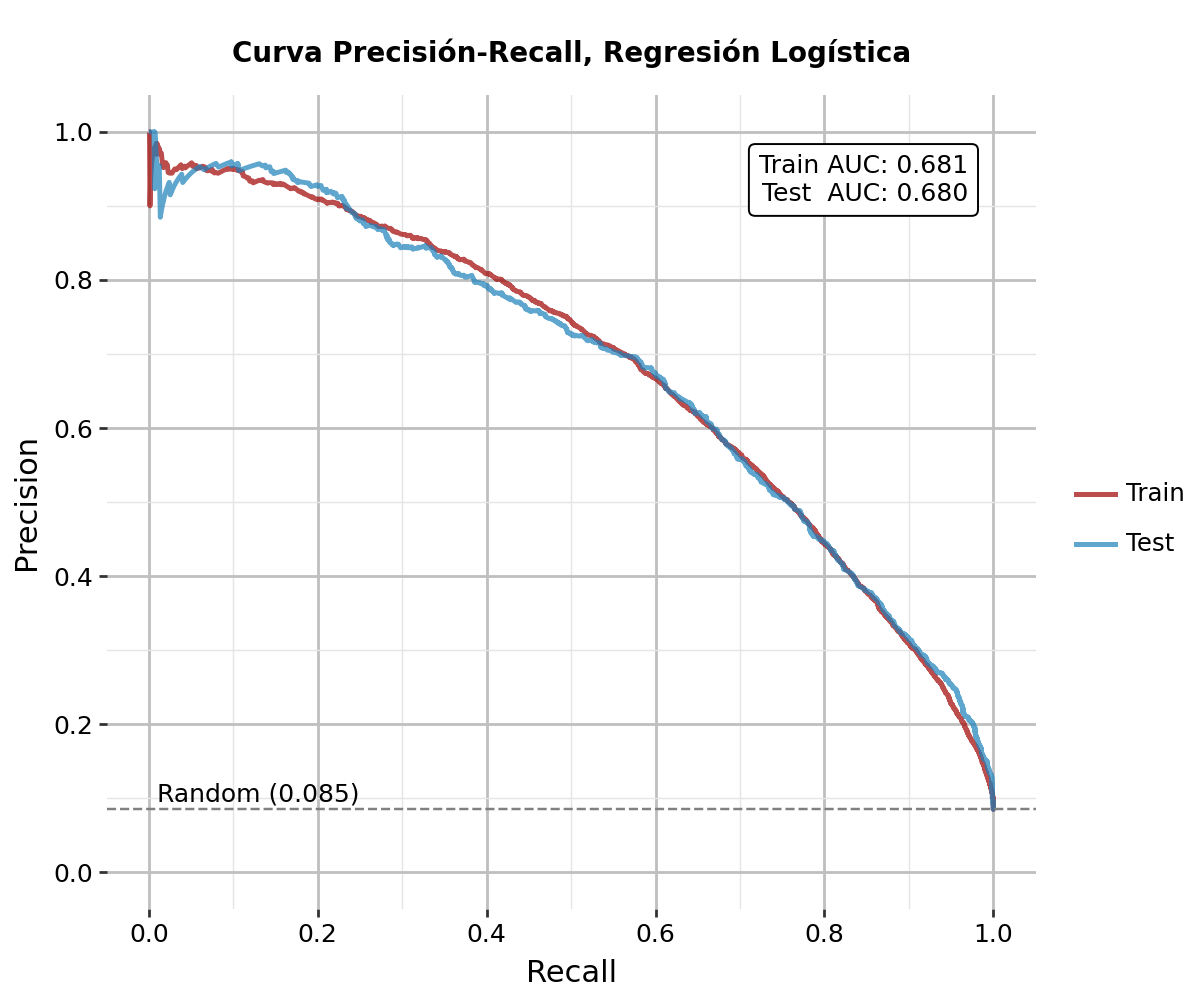

In [92]:
df_plot = up.df_pr_curve(X_train, y_train, X_test, y_test, final_model_pipe)
auc_label = up.auc_box(X_train, y_train, X_test, y_test, final_model_pipe)
random_level = y_train.mean()  # Nivel de precisión aleatoria (proporción de positivos en train)
pr_curve = up.pr_curve_plot(df_plot,
                 random_level,
                 auc_label,
                 title='Curva Precisión-Recall, Regresión Logística').show()

## 7.3 Matrices de confusión

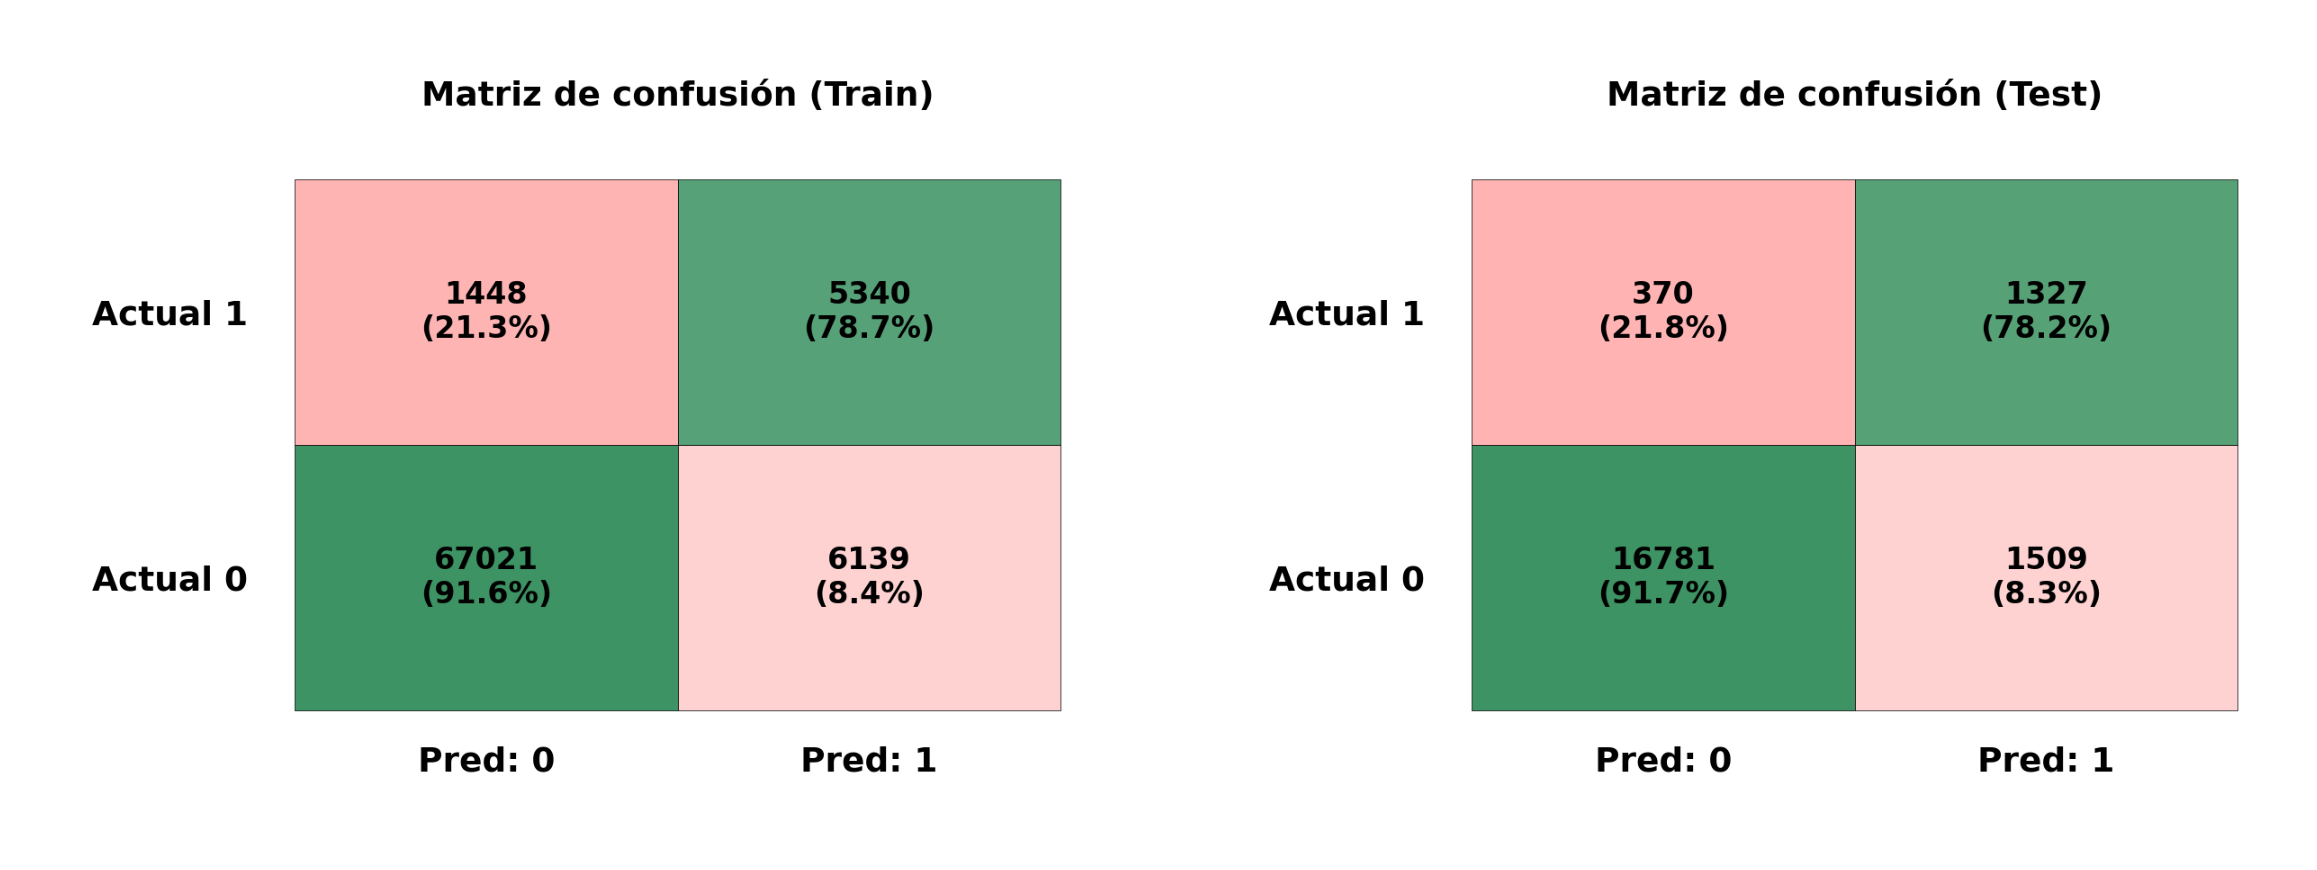

In [17]:
# Train
preds_train = final_model_pipe.predict_proba(X_train)[:, 1]
cm_train = confusion_matrix(y_train, (preds_train >= opt_t).astype(int))
cm_train = up.plot_confusion_matrix(cm_train,
                                    size = (4,3),
                                    title="Matriz de confusión (Train)")

# Test
preds_test = final_model_pipe.predict_proba(X_test)[:, 1]
cm_test = confusion_matrix(y_test, (preds_test >= opt_t).astype(int))
cm_test = up.plot_confusion_matrix(cm_test,
                                   size = (4,3),
                                   title="Matriz de confusión (Test)")

show_all = ut.join_plots([cm_train,cm_test],
                         [(4,3),(4,3)]
                        )

plt.tight_layout()
plt.show()

---
## 8. Interpretabilidad

### WOE Mappings

Cada feature transformada tiene un mapping que muestra:
- Para **WOE**: categoría original → `woe_raw` (WOE calculado) y `woe_model` (lo que ve el modelo, con signo invertido)
- Para **Binning**: bin → `woe_raw` y `IV` (Information Value, poder predictivo de cada bin)

**Interpretación**: `woe_model` positivo = mayor riesgo de diabetes. Un coeficiente negativo en el modelo multiplica a `woe_model`, por lo que contribuciones netas altas (positivas) se dan cuando signos coinciden.

### Train transformado

Primeras filas del dataset de entrenamiento después de aplicar el pipeline completo (TypeCaster → ColumnMapper → ColumnConfigPreprocessor). Cada columna contiene el valor WOE o binned que el modelo realmente usa.

In [40]:
X_train_tf = final_model_pipe[:-1].transform(X_train)
display(X_train_tf.head(10).style.format({col: '{:.4f}' for col in X_train_tf.columns}))

,smoking_history,hypertension,heart_disease,age,bmi,HbA1c_level,blood_glucose_level
15163,-0.2236,0.2260,0.1314,0.3538,1.0790,1.8097,1.6126
41142,0.7741,0.2260,0.1314,4.2006,2.3983,1.8097,1.6126
20453,-0.1184,-1.4383,0.1314,-0.1117,0.2953,0.0946,0.1996
45884,-0.1184,0.2260,0.1314,2.1685,0.2953,0.0946,-1.8091
45480,-0.1184,0.2260,0.1314,1.1257,0.2953,0.0946,-1.8091
60415,0.7741,0.2260,0.1314,4.2006,2.3983,1.8097,0.1996
97948,-0.1184,0.2260,0.1314,1.1257,0.6105,0.1210,1.6126
5067,0.7741,0.2260,0.1314,-1.0035,-0.8869,1.8097,1.6126
51370,0.7741,0.2260,0.1314,2.8432,2.3983,1.8097,0.1996
40539,-0.1184,0.2260,0.1314,-1.0035,-0.2535,1.8097,0.1996


---
### Perfil de cada feature

Grafico de barras (frecuencia normalizada) + linea (tasa de diabetes) por categoria/bin, ordenado por proporcion de target=1. Muestra la monotonia de la relacion WOE y la distribucion de cada categoria.

In [100]:
final_model_pipe[:-1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('type_cast', ...), ('smoke_map', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['hypertension', 'heart_disease']"
,dtype,<class 'str'>
,column,'smoking_history'
,mapping,"{'No Info': 'No Info', 'current': 'current', 'ever': 'former', 'former': 'former', ...}"
,column_config,"{'HbA1c_level': {'max_bins': 5, 'transform': 'binning'}, 'age': {'max_bins': 8, 'transform': 'binning'}, 'blood_glucose_level': {'max_bins': 4, 'transform': 'binning'}, 'bmi': {'max_bins': 8, 'transform': 'binning'}, ...}"


In [101]:
preproc_feat = final_model_pipe[:-1]

x_train_tf = preproc_feat.transform(X_train)

x_train_tf

,smoking_history,hypertension,heart_disease,age,bmi,HbA1c_level,blood_glucose_level
15163,-0.223560,0.225959,0.131395,0.353835,1.079046,1.809661,1.612593
41142,0.774097,0.225959,0.131395,4.200568,2.398289,1.809661,1.612593
20453,-0.118364,-1.438288,0.131395,-0.111718,0.295259,0.094640,0.199551
45884,-0.118364,0.225959,0.131395,2.168497,0.295259,0.094640,-1.809115
45480,-0.118364,0.225959,0.131395,1.125706,0.295259,0.094640,-1.809115
...,...,...,...,...,...,...,...
5457,-0.223560,0.225959,0.131395,2.168497,-0.608080,1.809661,0.199551
82768,-0.223560,0.225959,0.131395,1.125706,0.610451,0.094640,-0.075264
7393,-0.118364,0.225959,0.131395,-1.003490,1.079046,0.094640,0.199551
45759,0.774097,0.225959,0.131395,-1.003490,-1.221560,-1.842499,-1.809115


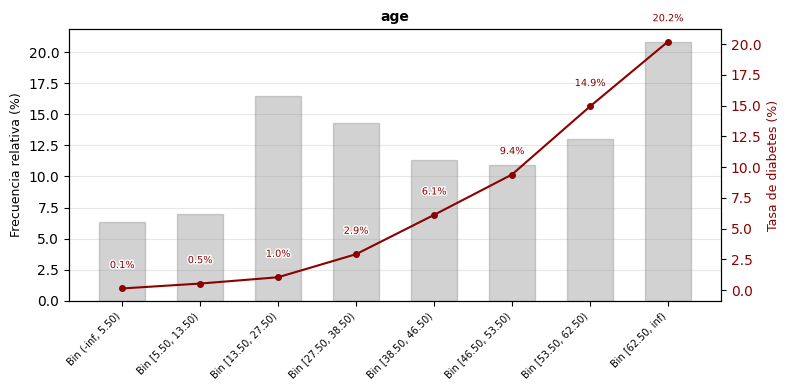

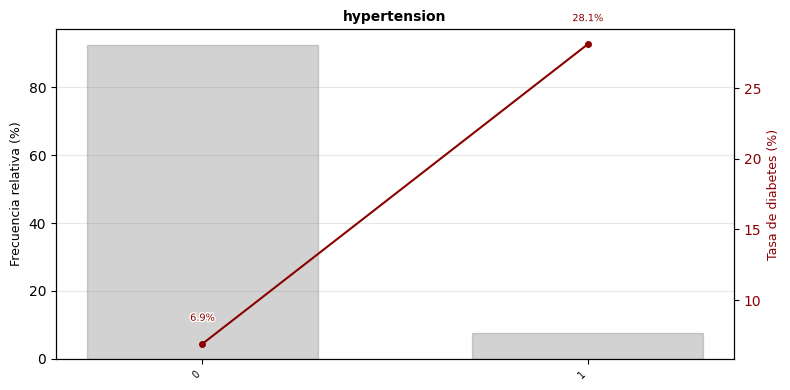

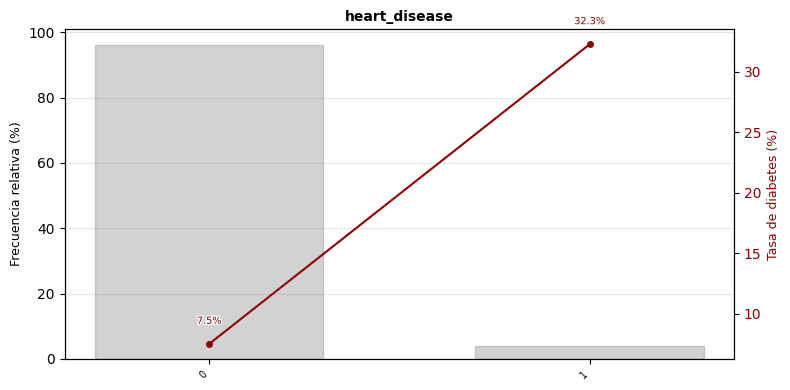

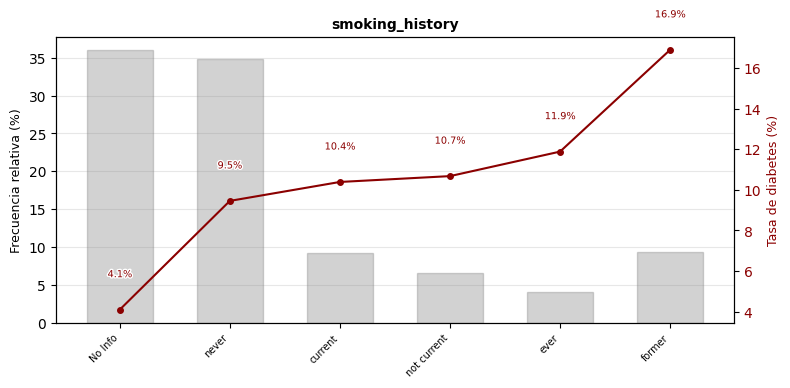

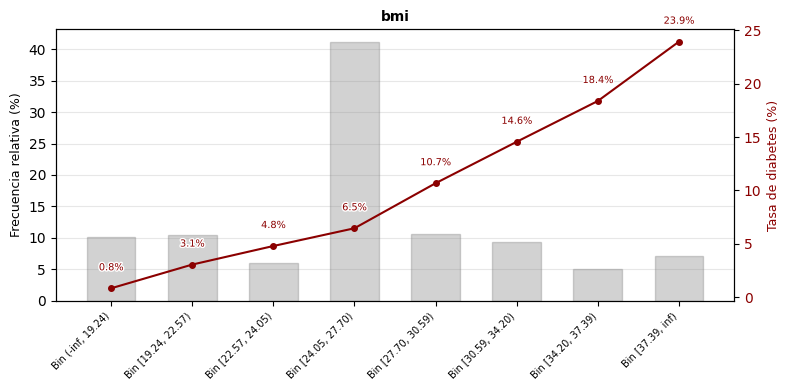

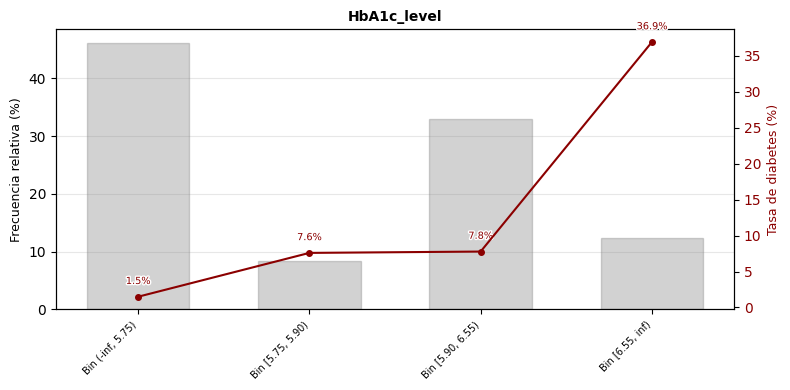

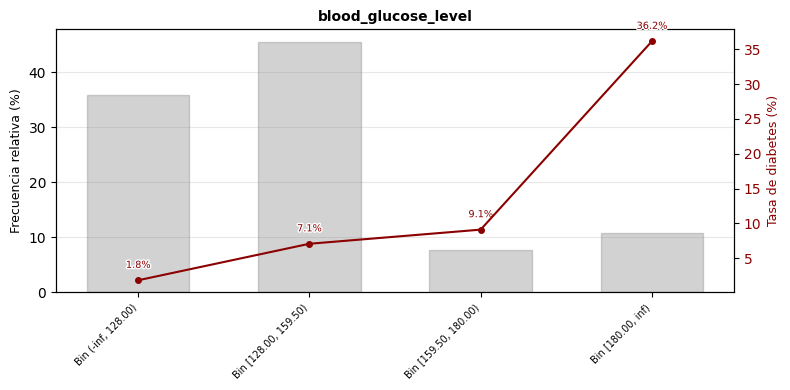

In [94]:
importlib.reload(up)

preproc_feat = final_model_pipe.named_steps['preprocessor']

for feat in X_train.columns.tolist():
    fig = up.plot_feature_profile(
        feature=feat,
        X_raw=X_train,
        y=y_train,
        column_config=column_config,
        preproc=preproc_feat,
        fig_size=(8, 4)
    )
    plt.show()

---
## Conclusiones

### 1. Hiperparámetros
- Mejor **C = 0.1** (regularización moderada)
- PR-AUC en CV: **~0.679**

### 2. Selección de features
- Backward elimination descartó **gender**, **smoking_history**, **heart_disease** e **hypertension** (todas las WOE categóricas)
- Subset óptimo (elbow ratio): **4 features numéricas**: `age`, `bmi`, `HbA1c_level`, `blood_glucose_level`
- **PR-AUC en Test: ~0.668** (pérdida marginal vs 0.680 con 8 features)

### 3. Interpretación de WOE
- **HbA1c_level** es el predictor más fuerte: IV = 0.84 en el bin superior (>6.55). `woe_model` negativo para valores altos = más riesgo
- **blood_glucose_level**: IV = 0.70 en el bin superior (≥180). Misma dirección: niveles altos incrementan riesgo
- **Age**: IV = 0.34 en el bin más joven (<5.5 años, protección) y 0.31 en el más mayor (≥62.5, riesgo)
- **Bmi**: obesidad (≥37.39) muestra el mayor riesgo relativo con IV = 0.17

### 4. Rendimiento del modelo
- **ROC-AUC ~0.936**: excelente discriminación global
- **Recall ~0.62-0.66**: identificamos ~2 de cada 3 diabéticos reales
- El threshold óptimo (~0.85) es alto debido al desbalance (92% no diabéticos)